In [2]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt


In [3]:
_path1 = 'C:\\Users\\hp\\Desktop\\3\\5.bmp'
img = cv2.imread(_path1)
print(img.shape)

(600, 600, 3)


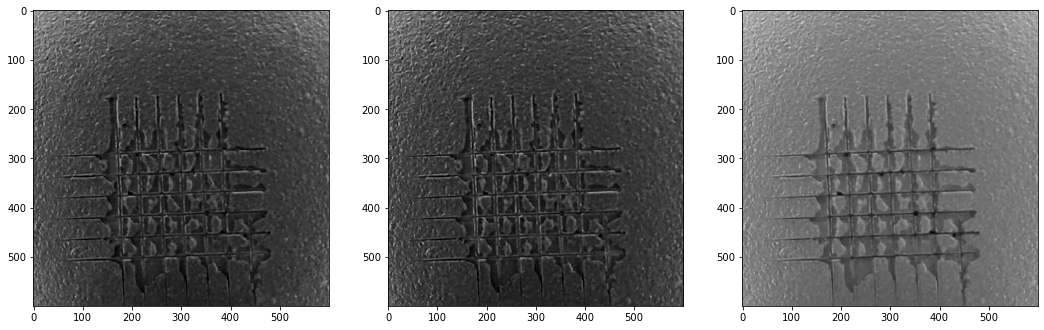

In [17]:
plt.figure(figsize=(18,24))
for i in range(0,3):
    plt.subplot(1,3,i+1)
    plt.imshow(img[:,:,i], cmap='gray')

In [4]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

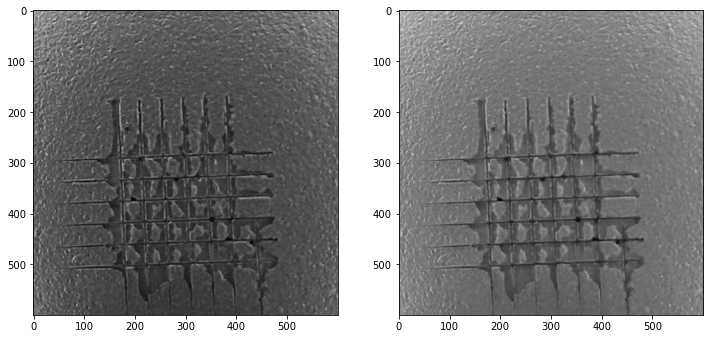

In [5]:
plt.figure(figsize=(12,24))
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(img_hsv[:,:,2], cmap='gray')

In [6]:
v_channel = img_hsv[:,:,-1]

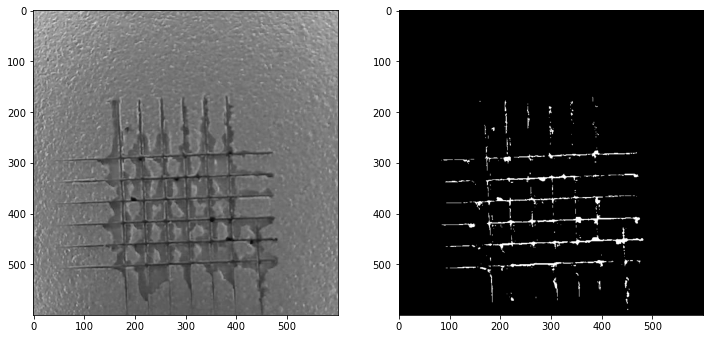

In [7]:
ret , v_th = cv2.threshold(v_channel, 60, 255, cv2.THRESH_BINARY_INV )
plt.figure(figsize=(12,24))
plt.subplot(1,2,1)
plt.imshow(v_channel, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(v_th, cmap='gray')

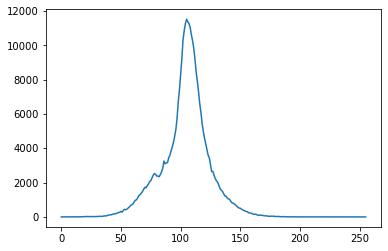

In [15]:
hist = cv2.calcHist([v_channel], [0], None, [256], [0,256])
plt.plot(hist)

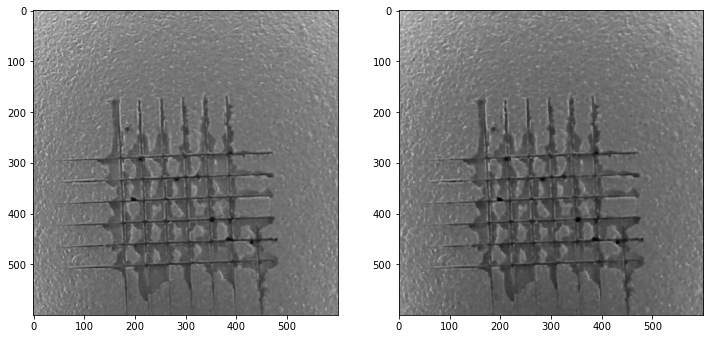

In [50]:
# 腐蚀膨胀
_se = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
# v_mpl = cv2.morphologyEx(v_channel, cv2.MORPH_OPEN, _se) # 形态学开操作，腐蚀+膨胀
v_mpl = cv2.morphologyEx(v_channel, cv2.MORPH_CLOSE, _se, iterations=1) # 形态学闭操作，膨胀+腐蚀
# v_mpl = cv2.morphologyEx(v_channel, cv2.MORPH_GRADIENT, _se) # 形态学梯度，膨胀-腐蚀
# v_mpl = cv2.morphologyEx(v_channel, cv2.MORPH_TOPHAT, _se) #顶帽， src-开操作
# v_mpl = cv2.morphologyEx(v_channel, cv2.MORPH_BLACKHAT, _se) # 黑帽， 闭操作-src
plt.figure(figsize=(12,24))
plt.subplot(1,2,1)
plt.imshow(v_channel, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(v_mpl, cmap='gray')

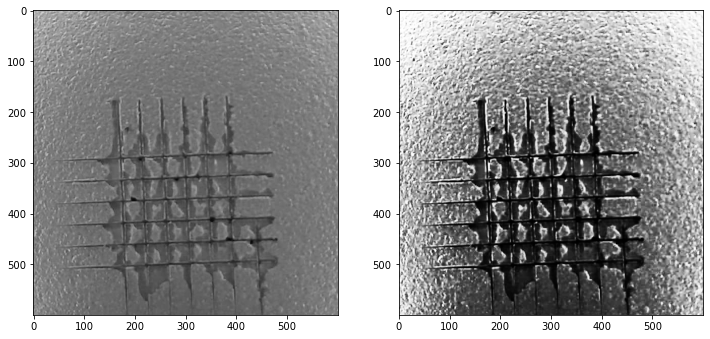

In [65]:
# 直方图均衡化
v_eh = cv2.equalizeHist(v_channel)
plt.figure(figsize=(12,24))
plt.subplot(1,2,1)
plt.imshow(v_channel, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(v_eh, cmap='gray')

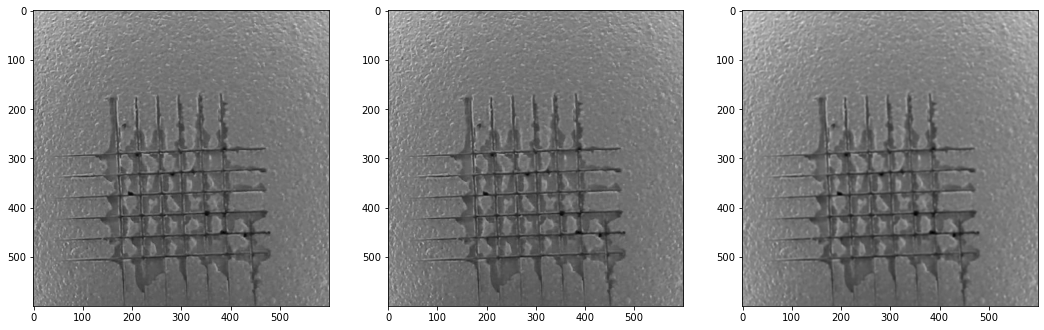

In [116]:
# 指数变换
# v_exp = v_channel.astype(np.float32)/255. 
# v_log = np.power(v_log, 1.8)
# v_exp = np.exp(v_exp)
from re import S


v_exp = np.zeros_like(v_channel)
cv2.normalize(v_channel, v_exp, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
v_exp_gauss = cv2.GaussianBlur(v_exp, (5,5), sigmaX=0)
# v_exp = (v_exp-v_exp.min())/(v_exp.max()-v_exp.min())
plt.figure(figsize=(18,24))
plt.subplot(1,3,1)
plt.imshow(v_channel, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(v_exp, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(v_exp_gauss, cmap='gray')

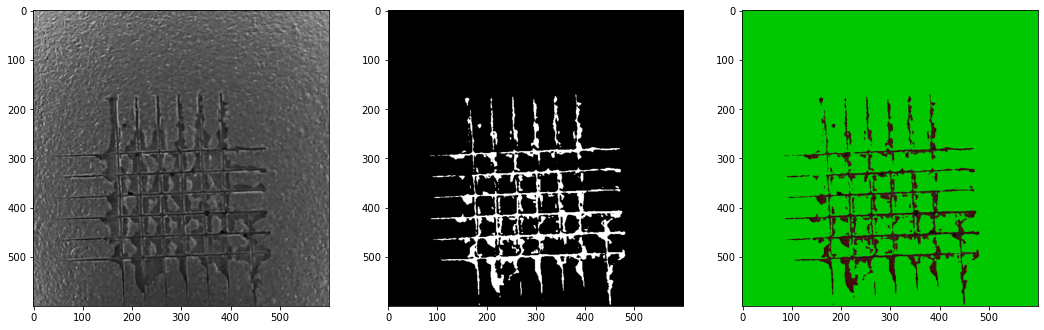

In [123]:
# ret , v_th = cv2.threshold(v_mpl, 91, 255, cv2.THRESH_BINARY )
ret , v_th = cv2.threshold(v_exp_gauss, 80, 255, cv2.THRESH_BINARY_INV )
# v_th = cv2.adaptiveThreshold(v_mpl, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,blockSize=7, C=0)
plt.figure(figsize=(18,24))
plt.subplot(1,3,1)
plt.imshow(img_gray, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(v_th, cmap='gray')
img_copy = img.copy()
img_copy[v_th == 0] = np.array([0,200, 0], dtype=np.uint8)
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))

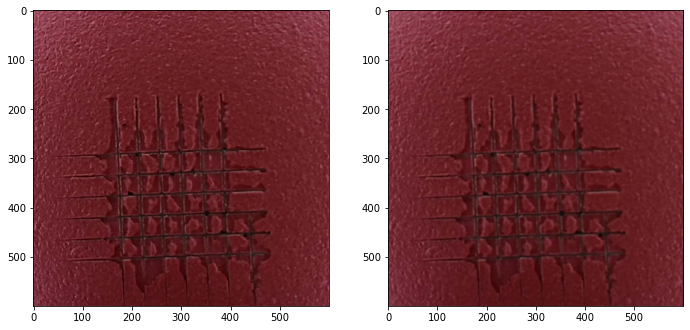

In [130]:
img_gauss = cv2.GaussianBlur(img, (5,5), sigmaX=0)
plt.figure(figsize=(18,24))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_gauss, cv2.COLOR_BGR2RGB))
# plt.subplot(1,3,3)
# plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))

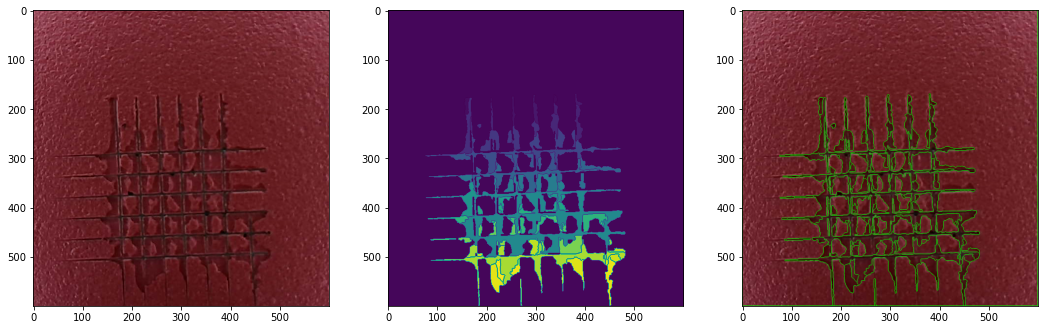

In [137]:
# 分水岭
ret ,qian_jing = cv2.threshold(v_exp_gauss, 75, 255, cv2.THRESH_BINARY_INV ) # 等于255的是前景
ret, bei_jing = cv2.threshold(v_exp_gauss, 110, 255, cv2.THRESH_BINARY_INV ) # 0是背景
unknow = cv2.subtract(bei_jing, qian_jing) # 255为未知区域
ret, markers = cv2.connectedComponents(qian_jing)
markers = markers + 1
markers[unknow == 255] = 0
markers = cv2.watershed(img_gauss, markers)

img_copy = img.copy()
img_copy[markers == -1] = (0, 255, 0)
plt.figure(figsize=(18,24))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2)
plt.imshow(markers)
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))



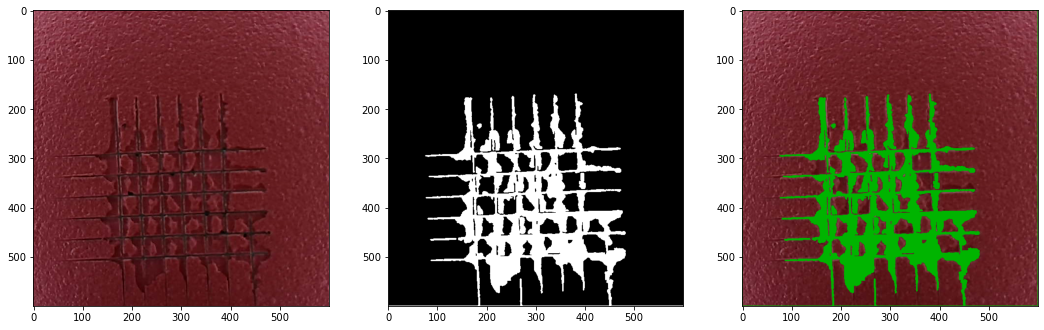

In [138]:
mask = np.ones_like(markers, dtype=np.uint8) * 255
mask[markers == 1] = 0
img_copy = img.copy()
img_copy[mask == 255] = (0,180,0)
plt.figure(figsize=(18,24))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))

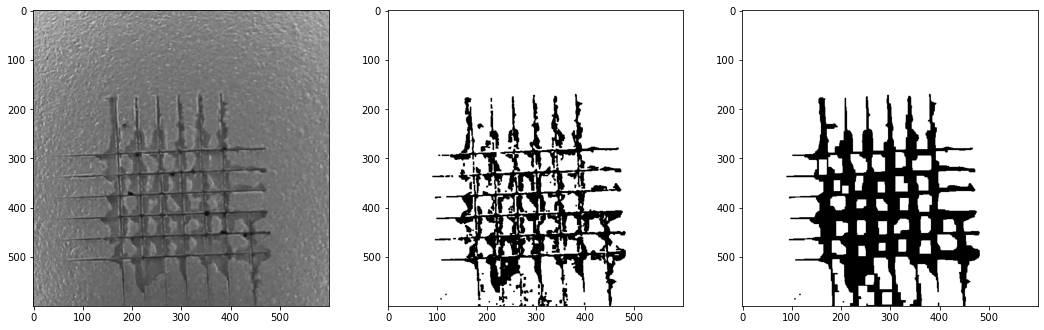

In [61]:
# 腐蚀膨胀
_se = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 13))
v_th_mpl = cv2.morphologyEx(v_th, cv2.MORPH_OPEN, _se) # 形态学开操作，腐蚀+膨胀
# v_th_mpl = cv2.morphologyEx(v_th, cv2.MORPH_CLOSE, _se, iterations=1) # 形态学闭操作，膨胀+腐蚀
# v_mpl = cv2.morphologyEx(v_channel, cv2.MORPH_GRADIENT, _se) # 形态学梯度，膨胀-腐蚀
# v_mpl = cv2.morphologyEx(v_channel, cv2.MORPH_TOPHAT, _se) #顶帽， src-开操作
# v_mpl = cv2.morphologyEx(v_channel, cv2.MORPH_BLACKHAT, _se) # 黑帽， 闭操作-src
plt.figure(figsize=(18,24))
plt.subplot(1,3,1)
plt.imshow(v_channel, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(v_th, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(v_th_mpl, cmap='gray')